[\[GitHub\] Jupyter Notebook](https://github.com/sslastochkin/mcab/blob/main/docs/guide/03_type_one_error.ipynb)
  
# Type I Error and Choosing a Test  

In this lesson we will:

1. Recall what Type I error is and why it matters in product decisions.
2. Learn to **measure actual α empirically** using A/A simulations via `designer.aa_sims()`.
3. Learn to **read the built-in diagnostic plot**: 4 panels, colour coding, text summary box.
4. Understand **how many simulations are enough** to trust the result.
5. **Compare statistical tests** for each metric type: iid, conversion, ratio with and without linearisation.
6. **Intentionally reduce α**: when a large sample lets you tighten the threshold from 0.05 → 0.01
   and how to use `mcab` to find the sample size that achieves it while keeping power ≥ 80%.

> **Prerequisites.** This lesson reuses the four datasets from Lesson 2.
> Run the data-generation cell first.


In [1]:
# Data Generation (sandbox data from prev lesson)
import numpy as np
from scipy import stats as scipy_stats
from mcab import (
    RandomData,
    AaDataIid,
    AaDataRatio,
    DesignerIid,
    DesignerRatio,
    DesignerRatioLin
)

# ── reproduce exactly the datasets from Lesson 2 ──────────────────────────────
rd = RandomData(42)

arpu_raw       = rd.exponential_data()        # ARPU — heavy-tailed
conversion_raw = rd.proportion_data()         # conversion 0/1
ctr_raw        = rd.ratio_data_ctr()          # CTR (clicks, impressions)
avg_bill_raw   = rd.ratio_data_avg_bill()     # avg bill (revenue, purchases)

print("Data shapes (same as Lesson 2):")
print(f"  arpu_raw:       {arpu_raw.shape}")
print(f"  conversion_raw: {conversion_raw.shape}")
print(f"  ctr_raw:        clicks={ctr_raw[0].shape}, impressions={ctr_raw[1].shape}")
print(f"  avg_bill_raw:   revenue={avg_bill_raw[0].shape}, purchases={avg_bill_raw[1].shape}")
print()
print(f"  ARPU       mean={arpu_raw.mean():.1f}  std={arpu_raw.std():.1f}")
print(f"  Conversion rate={conversion_raw.mean():.3f}")
print(f"  CTR        overall={ctr_raw[0].sum()/ctr_raw[1].sum():.4f}")
print(f"  Avg bill   overall={avg_bill_raw[0].sum()/avg_bill_raw[1].sum():.1f}")


Data shapes (same as Lesson 2):
  arpu_raw:       (10000,)
  conversion_raw: (10000,)
  ctr_raw:        clicks=(10000,), impressions=(10000,)
  avg_bill_raw:   revenue=(10000,), purchases=(10000,)

  ARPU       mean=988.7  std=992.5
  Conversion rate=0.508
  CTR        overall=0.0500
  Avg bill   overall=497.5


## 1. What Is Type I Error (and Why It Costs Money)?

> **Type I error (α)** — the probability of declaring an effect significant when there is none.  
> In A/B testing: the test fires **"winner!"** on a neutral or even harmful feature.

Setting α = 0.05 means: *in a world where nothing changed, your test should fire incorrectly
in at most 5 % of experiments.*

**Why this matters in practice:**

| Situation | Consequence |
|---|---|
| Actual α ≫ 0.05 | Neutral (or harmful) features ship as "winners". Bad decisions accumulate. |
| Actual α ≪ 0.05 | Test is too conservative; real improvements go undetected. |
| α nominally 0.05 but actually 0.19 | Every 5th A/A test looks "significant" — garbage-in, garbage-out decisions. |

The key insight: **the nominal α you set and the actual α your test delivers are often different.**  
The only reliable way to verify actual α is to run A/A simulations on real data.


## 2. Measuring Actual α with `aa_sims()`

An A/A simulation answers the question directly:

> *"If both groups are drawn from the same distribution (no effect),  
> what fraction of the time does my test still fire?"*

**Algorithm:**

1. Take historical data — by definition no effect exists.
2. Repeat `n_sims` times: randomly split users into "test" and "control".
3. Run **the exact test** you plan to use in production.
4. Count how many times `p < α`. That fraction is the empirical Type I error.

`designer.aa_sims(plot=True)` automates this and produces a **4-panel diagnostic figure**.


Simulations:   0%|          | 0/3000 [00:00<?, ?sim/s]

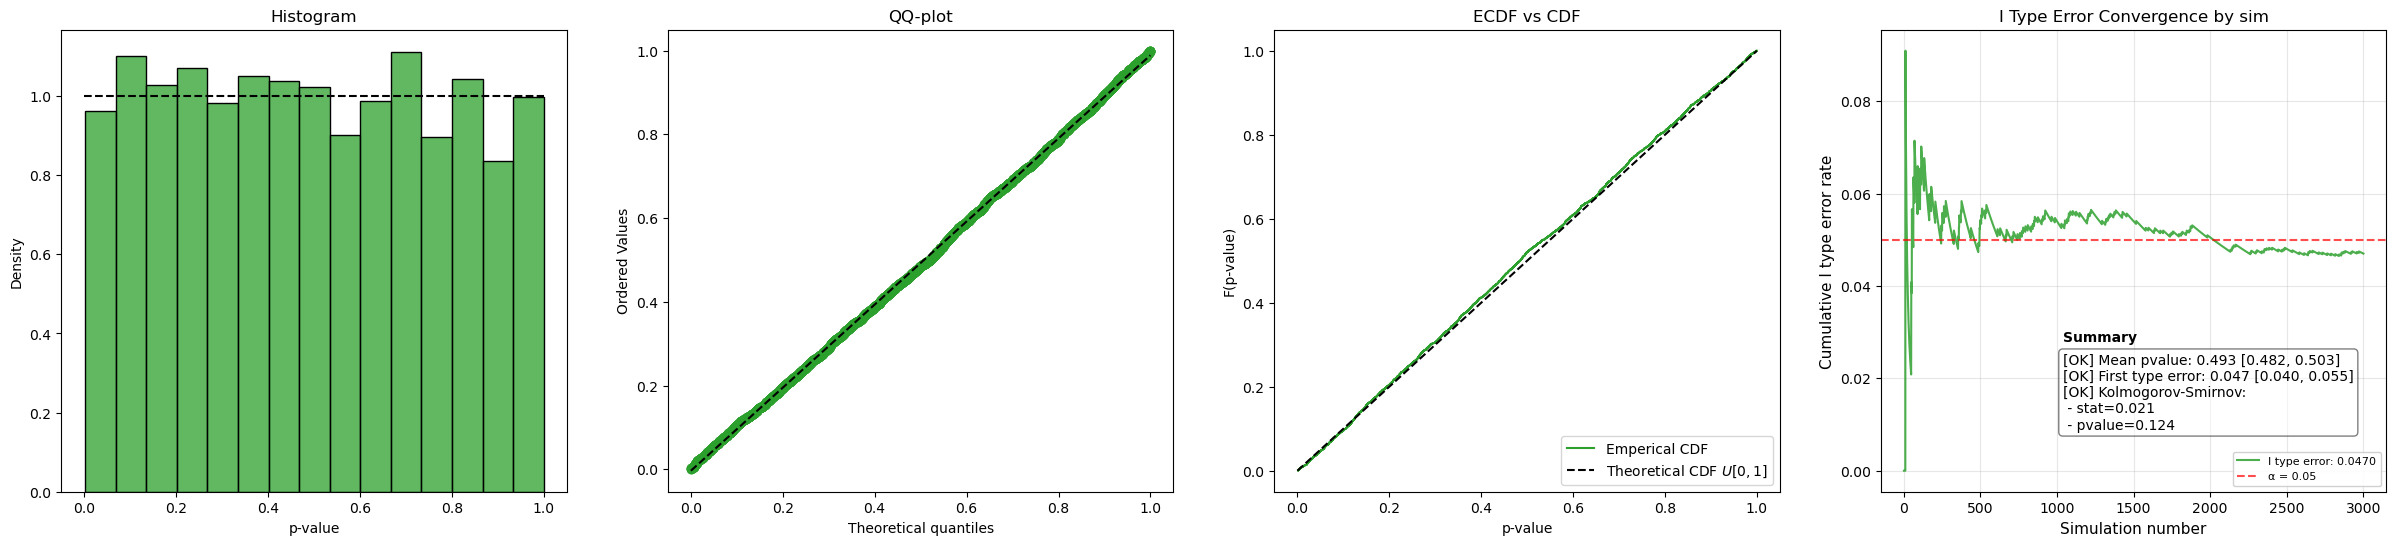

In [ ]:
ttest = lambda t, c: scipy_stats.ttest_ind(t, c).pvalue

arpu_designer = DesignerIid(
    AaDataIid(arpu_raw), # change "arpu_raw" to your actual data
    alpha=0.05,
    seed=42,
)

pvals_arpu = arpu_designer.aa_sims(
    pval_func=ttest,
    n_sims=3_000,
    control_size=0.5,
    plot=True,        # <— show the 4-panel diagnostic plot
    verbose=True,
    n_jobs=-1,
)


### How to Read the Diagnostic Plot

`aa_sims(plot=True)` shows **4 panels in one row**:

| Panel | What it shows | What a calibrated test looks like |
|---|---|---|
| **Histogram** | Distribution of all p-values | Flat bar chart — each bin ≈ 1/20 of all values |
| **QQ-plot** | p-value quantiles vs. Uniform(0,1) quantiles | Points lie on the diagonal y = x |
| **ECDF** | Empirical CDF of p-values vs. theoretical CDF | Step-line matches the red dashed diagonal |
| **Convergence** | Cumulative FPR as simulations accumulate; text summary box | Line stabilises near α = 0.05; box shows `[OK]` on all three checks |

**Colour coding (applies to all 4 panels simultaneously):**

- 🟢 **Green** — all three checks pass:
  - 95 % CI for mean p-value **contains 0.50**
  - 95 % CI for FPR has its **left bound ≤ α**
  - KS test **p-value ≥ 0.05** (p-values are consistent with Uniform)
- 🟠 **Orange** — partial issue: one check fails but not all
- 🔴 **Red** — serious miscalibration: mean p-value CI does **not** contain 0.50 **and** FPR is inflated

**The text summary box on the convergence panel** shows exactly:  
Any `[X]` here instead of `[OK]` means the test is miscalibrated — you should switch to a different test
before running the real experiment.

### How Many Simulations Are Enough?

Read the **convergence panel** (panel 4): the cumulative FPR line should have **flattened out**
by the end of the x-axis.

If the line is still bouncing at the right edge → increase `n_sims`.

**Rule of thumb for CI half-width ≈ ±0.01 around the estimate:**

| Target α | Required `n_sims` |
|---|---|
| 0.05 | ≥ 2 000 |
| 0.01 | ≥ 5 000 |
| 0.005 | ≥ 10 000 |

The formula: $\text{CI half-width} \approx \dfrac{1.96\sqrt{\alpha(1-\alpha)}}{\sqrt{n_{\text{sims}}}}$

**Practical check:** after running, look at the last ~20 % of the convergence line.
If the range there is < 0.005 — the estimate is stable.
  
Let's look at examples of enough and not enough number of simulations:

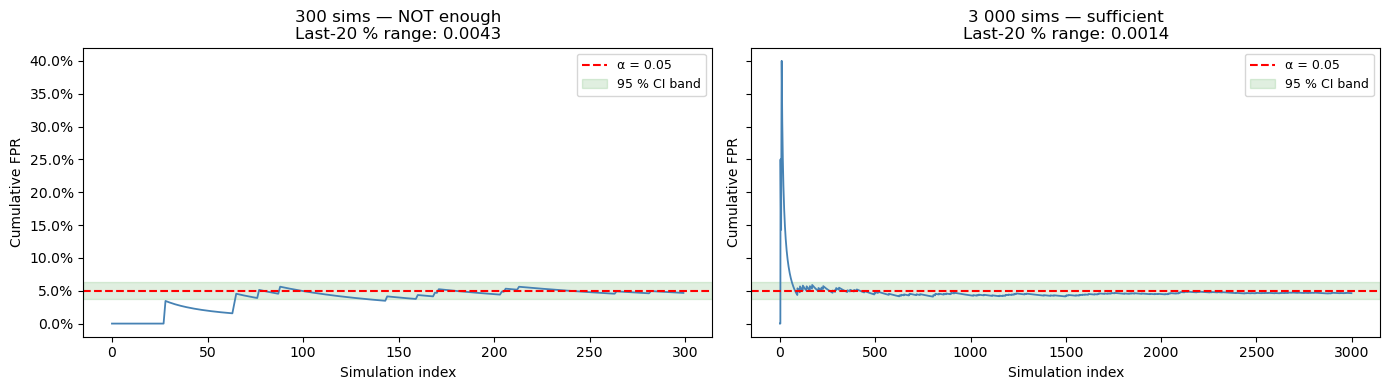

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, n_sims, title in [
    (axes[0], 300,   '300 sims — NOT enough'),
    (axes[1], 3_000, '3 000 sims — sufficient'),
]:
    pv = arpu_designer.aa_sims(
        pval_func=ttest, n_sims=n_sims, control_size=0.5,
        plot=False, verbose=False,
    )
    cum = np.cumsum(pv < 0.05) / np.arange(1, n_sims + 1)
    ax.plot(cum, lw=1.3, color='steelblue')
    ax.axhline(0.05, color='red', lw=1.5, ls='--', label='α = 0.05')
    ax.axhspan(0.037, 0.063, alpha=0.12, color='green', label='95 % CI band')
    last20pct = cum[int(0.8 * n_sims):]
    ax.set_title(f'{title}\nLast-20 % range: {np.ptp(last20pct):.4f}')
    ax.set_xlabel('Simulation index')
    ax.set_ylabel('Cumulative FPR')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()


## 3. Choosing the Right Statistical Test

A test that is perfectly calibrated for ARPU can be completely wrong for CTR.

**Strategy:**
1. Pick 2–3 candidate tests.
2. Run `aa_sims(plot=True)` for each.
3. Keep only 🟢 green tests.
4. Among green ones, pick the one with the lowest MDE (covered in Lesson 6).

> If test is not green - try relaunch simulation or increase `n_sims` parameter.
> If metrik is proportion with low variance reducing number of simulations is an option.  

Below we go through all four metric types from Lesson 2.

=== ARPU — t-test ===


Simulations:   0%|          | 0/3000 [00:00<?, ?sim/s]

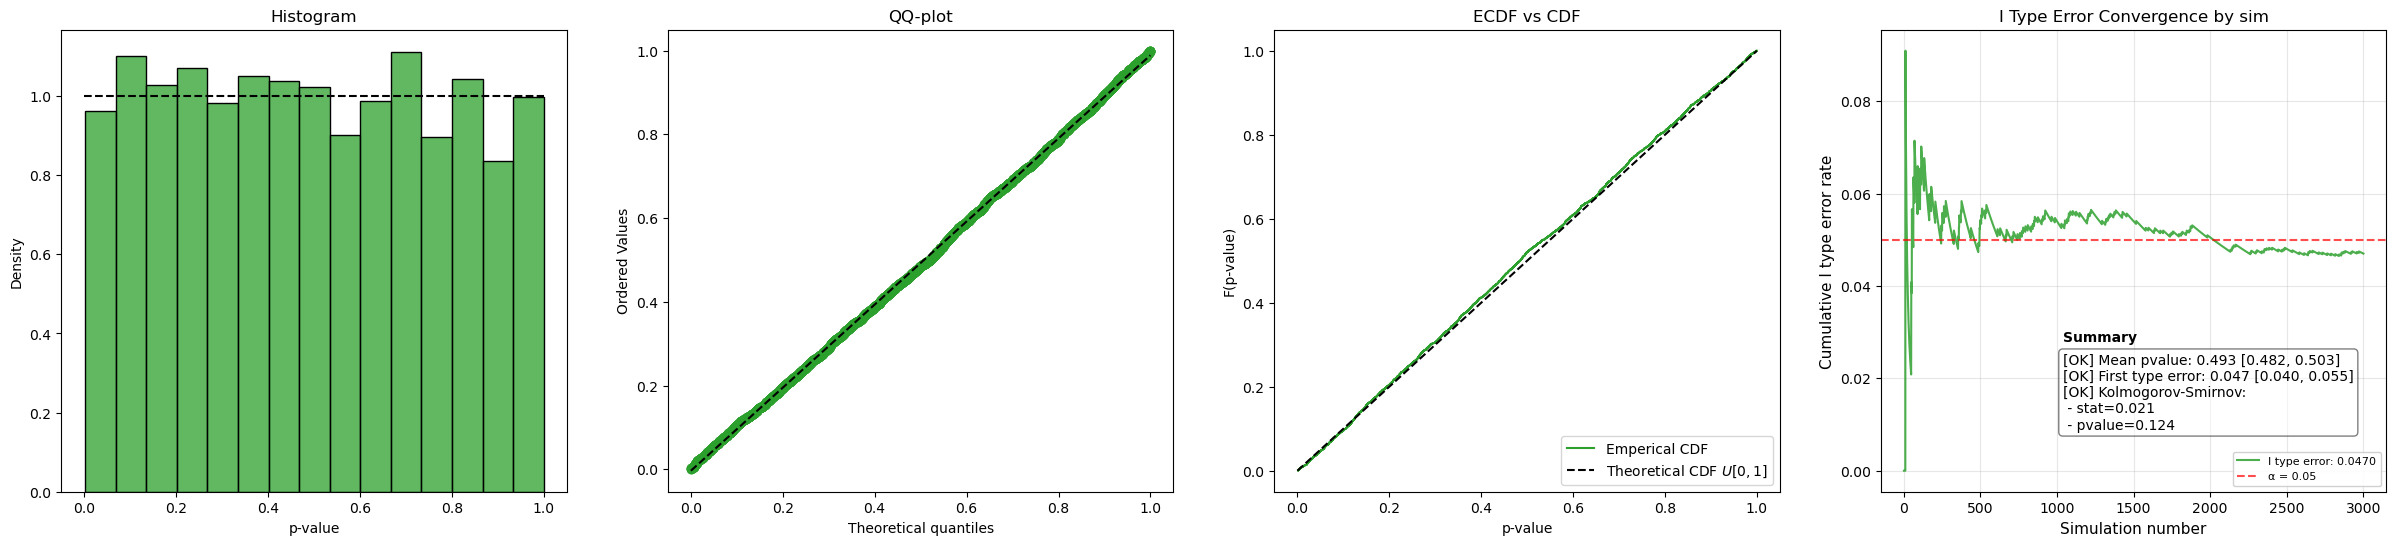

In [4]:
# ── 3.1 ARPU (heavy-tailed exponential distribution) ─────────────────────────
print("=== ARPU — t-test ===")
_ = DesignerIid(AaDataIid(arpu_raw), alpha=0.05, seed=42).aa_sims(
    pval_func=ttest,
    n_sims=3_000, control_size=0.5, plot=True, verbose=True, n_jobs=-1,
)


=== ARPU — Mann-Whitney U ===


Simulations:   0%|          | 0/3000 [00:00<?, ?sim/s]

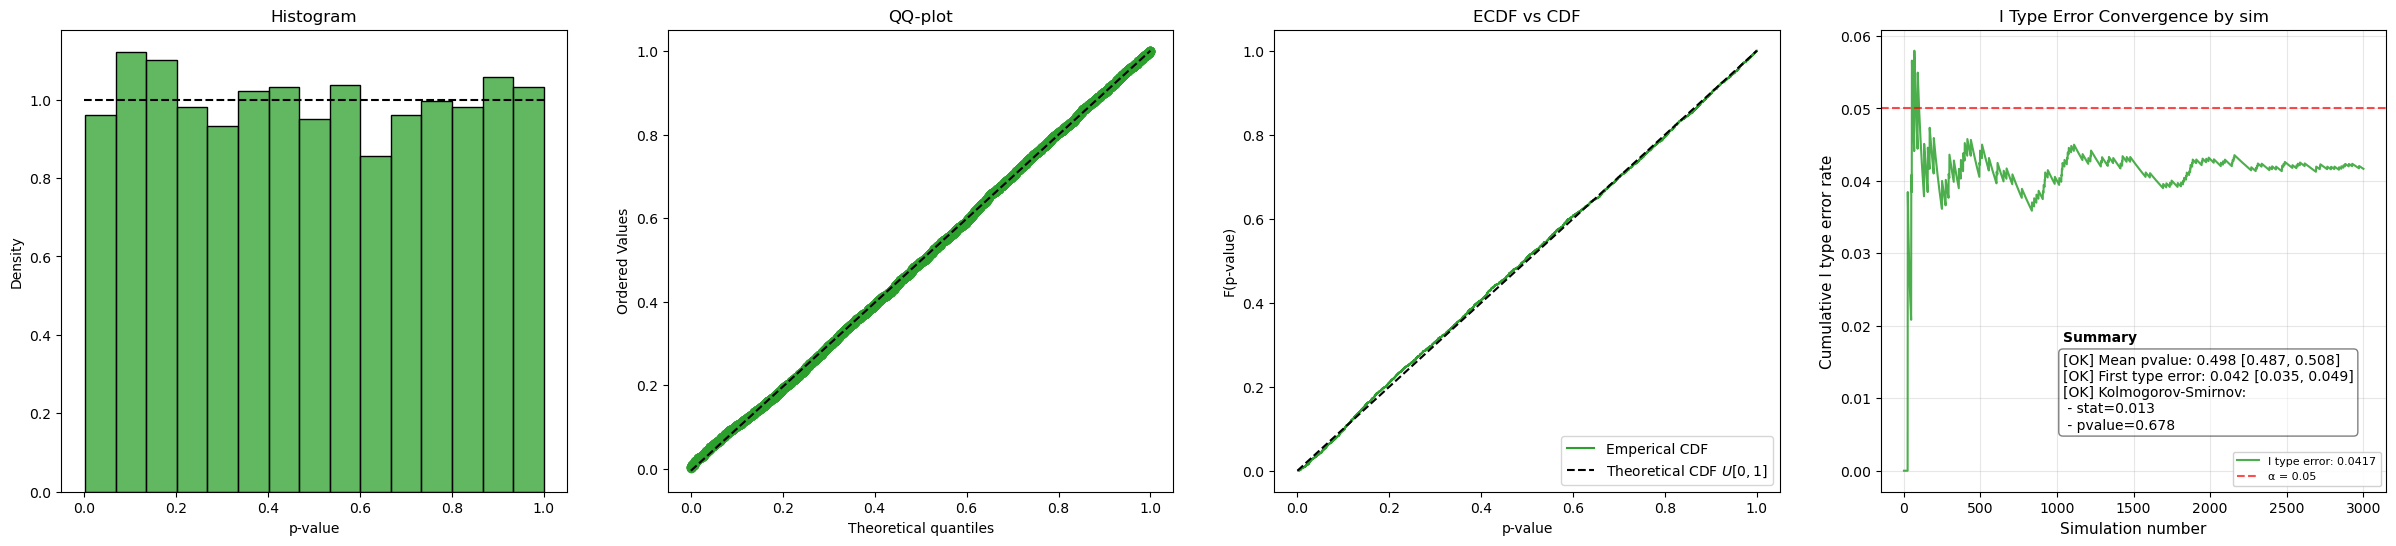

In [5]:
mwu = lambda t, c: scipy_stats.mannwhitneyu(t, c, alternative='two-sided').pvalue

print("=== ARPU — Mann-Whitney U ===")
_ = DesignerIid(AaDataIid(arpu_raw), alpha=0.05, seed=42).aa_sims(
    pval_func=mwu,
    n_sims=3_000, control_size=0.5, plot=True, verbose=True, n_jobs=-1,
)


### Conversion (0/1 data)

For binary outcomes the t-test on 0/1 values is asymptotically equivalent to a
two-proportion z-test and is correctly calibrated.  
We verify this directly.


=== Conversion — t-test ===


Simulations:   0%|          | 0/1000 [00:00<?, ?sim/s]

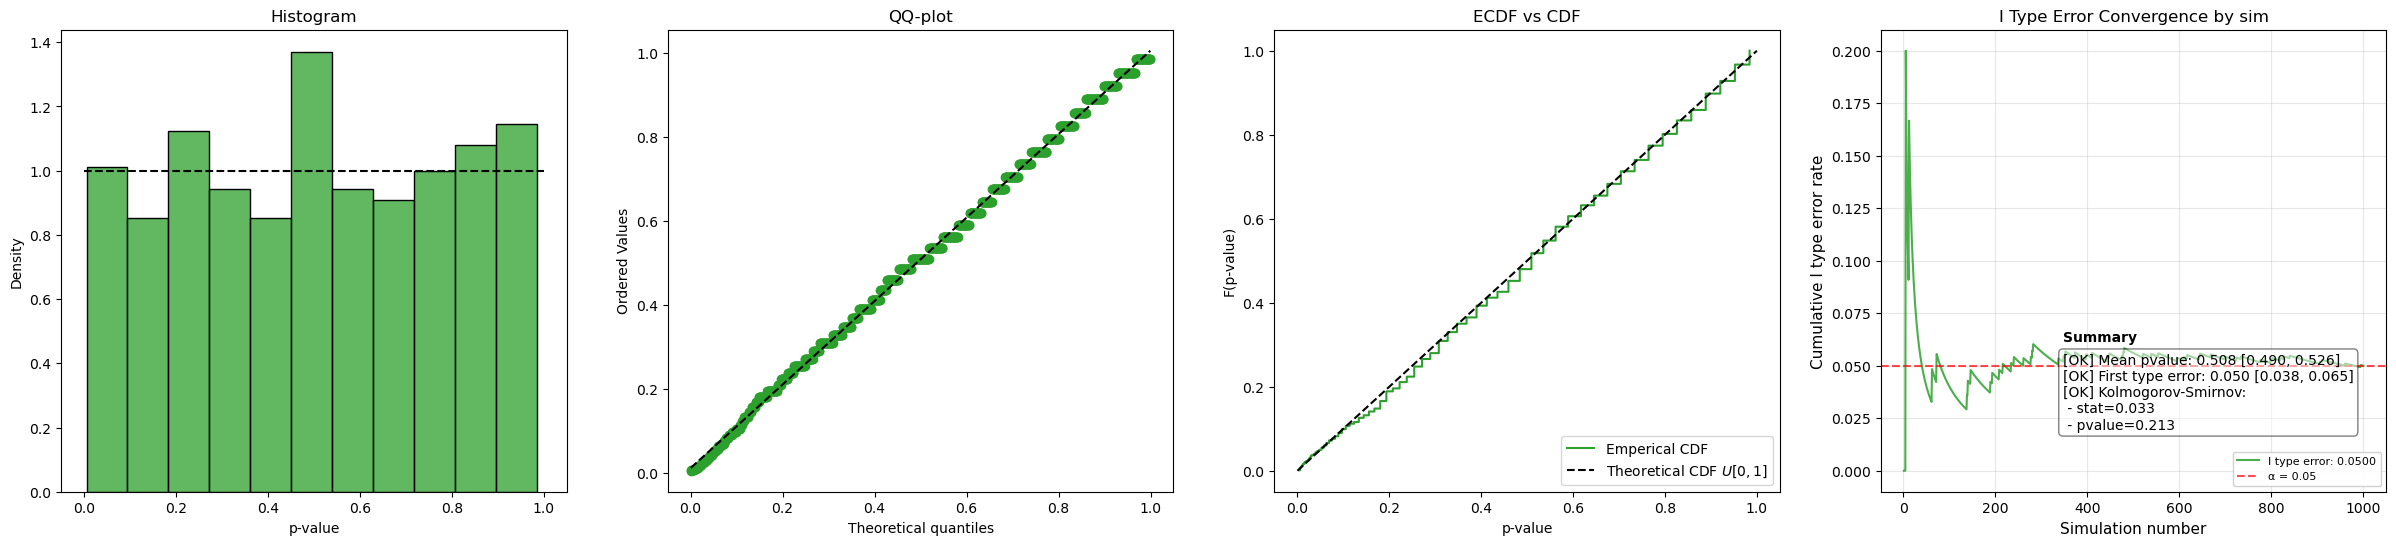

In [8]:
# ── 3.2 Conversion (Bernoulli 0/1) ───────────────────────────────────────────
print("=== Conversion — t-test ===")
_ = DesignerIid(AaDataIid(conversion_raw, proportion=True), alpha=0.05, seed=42).aa_sims(
    pval_func=ttest,
    n_sims=1_000, control_size=0.5, plot=True, verbose=True, n_jobs=-1,
)


But see: our metrik has low variance and if we will make too much simulations distribution of pvalues will be more close to discrete distribution than to the uniform. It's not an issue it's a feature of proportion data we should remember:

Simulations:   0%|          | 0/5000 [00:00<?, ?sim/s]

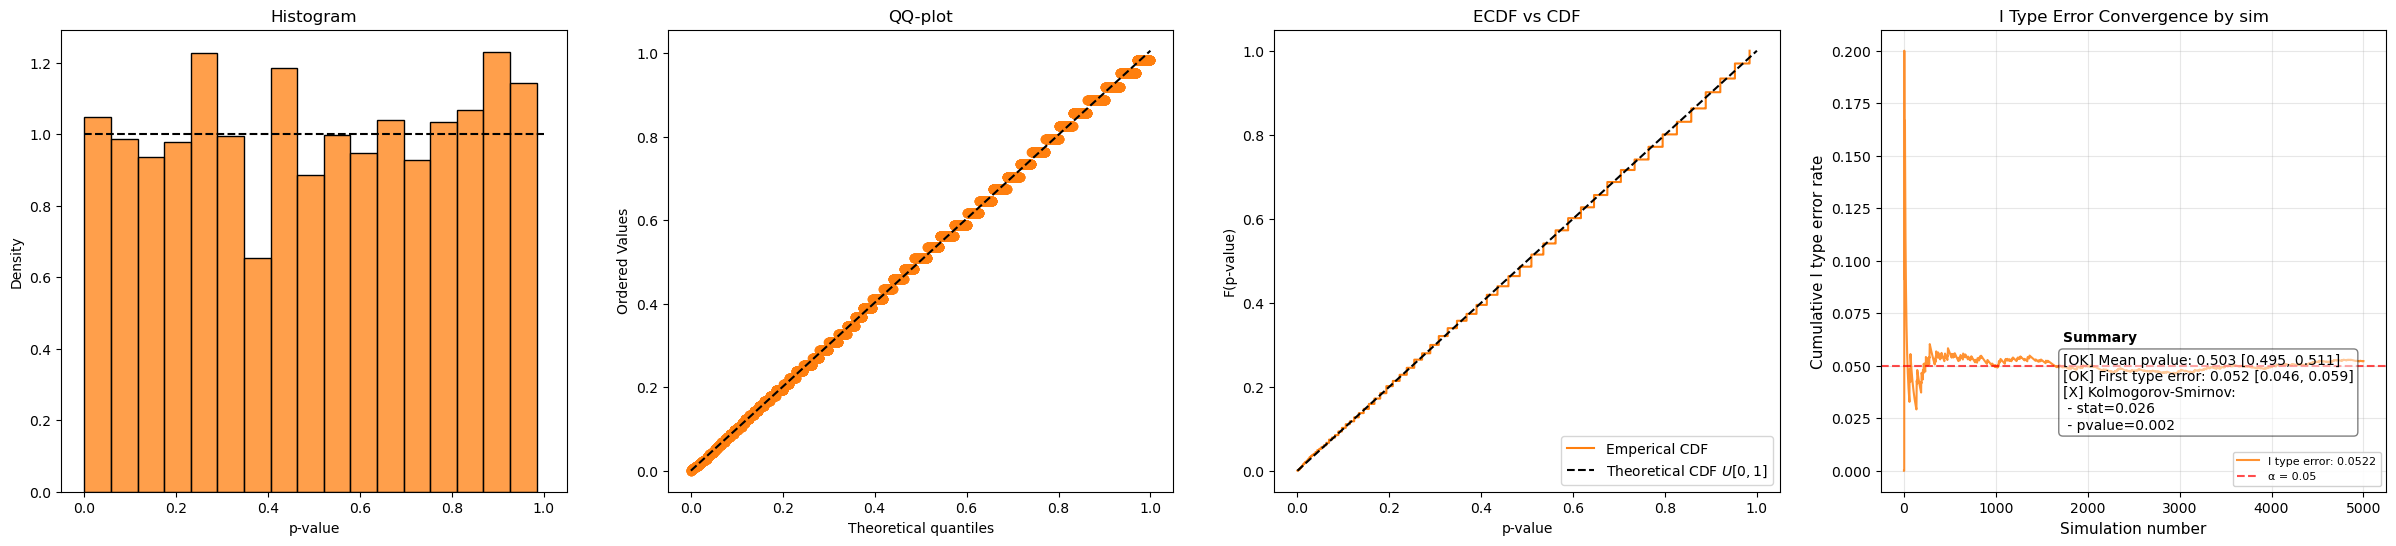

In [18]:
_ = DesignerIid(AaDataIid(conversion_raw, proportion=True), alpha=0.05, seed=42).aa_sims(
    pval_func=ttest,
    n_sims=5_000, # was 1000 in previous launch, other is same
    control_size=0.5, plot=True, verbose=True, n_jobs=-1,
)


_Comment to plot:_ Mean p-value and first type error rate are ok.  
Kolmogorov-Smirnov test of distribution uniformity breaks because of too much simulations for data with too low variance.

### Ratio Metrics: With and Without Linearisation

For ratio metrics (CTR = clicks / impressions, avg bill = revenue / purchases) there are two
approaches:

| Approach | Designer | `pval_func` receives | When to prefer |
|---|---|---|---|
| **Per-user ratio** | `DesignerRatio` | `(test_tuple, ctrl_tuple)` — each is `(num, denom)` | Simple, robust |
| **Linearised (delta method)** | `DesignerRatioLin` | `(test_tuple, ctrl_tuple)` — each is `(num, denom)` | Better power for large N; standard in mature platforms |

The linearised metric is `lin_i = num_i − θ̂ · denom_i` where `θ̂ = Σnum / Σdenom`
from the control group. It collapses the ratio into a single number per user,
reducing variance and enabling standard tests.  
  
You dont need make any transformations, mcab backend will do it for you.  
The reason you might look at linearization is ability to make ratio data iid and apply stratification and cuped we will talk in next lessons.

=== CTR — per-user ratio t-test (DesignerRatio) ===


Simulations:   0%|          | 0/3000 [00:00<?, ?sim/s]

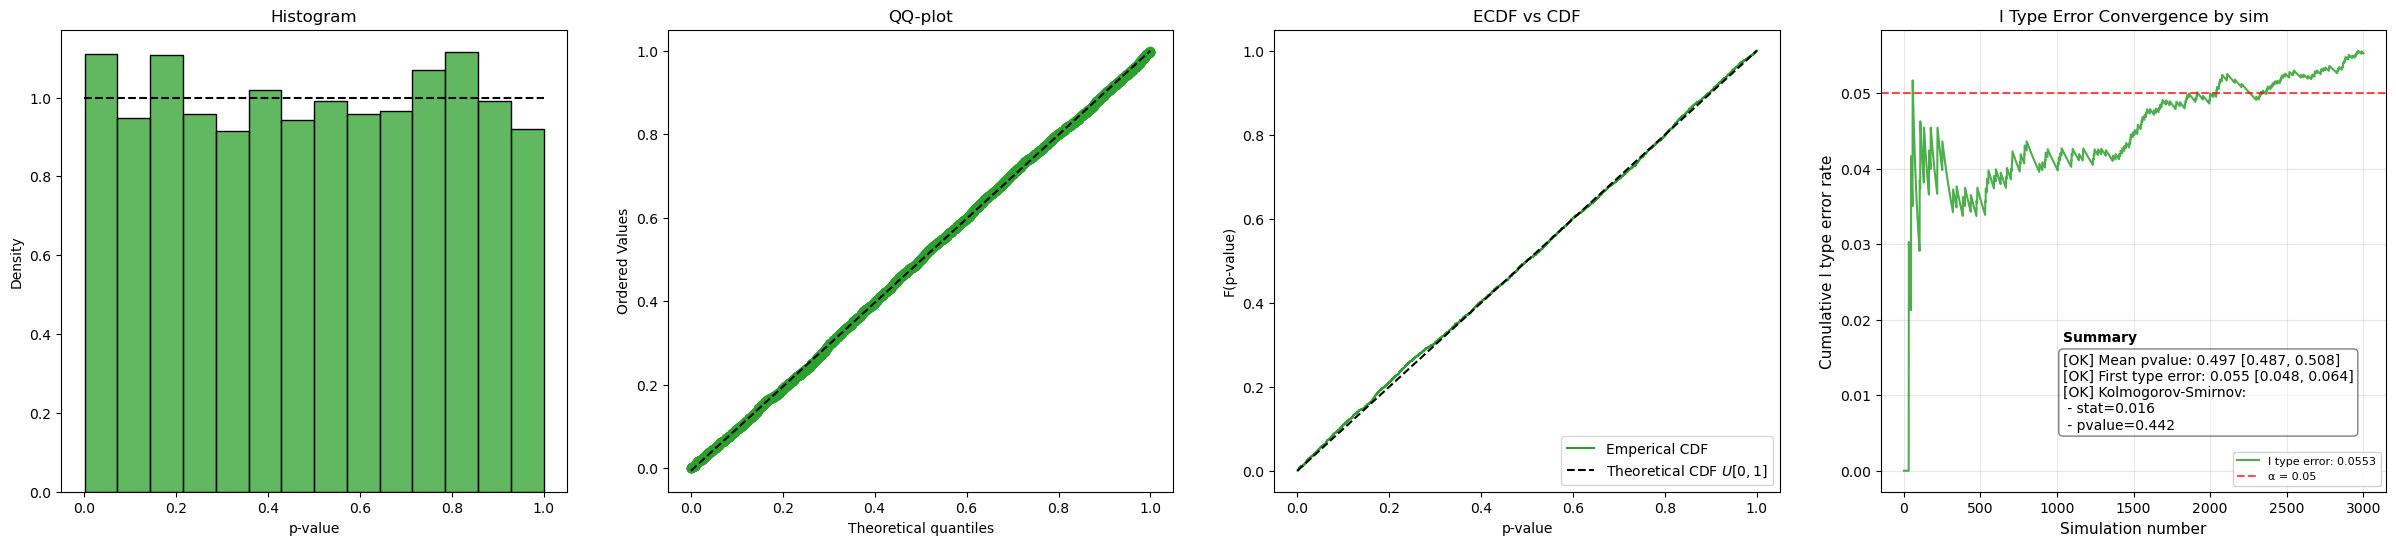

In [9]:
# ── 3.3 CTR — per-user t-test via DesignerRatio ───────────────────────────────
def ctr_ttest_ratio(test_tuple, ctrl_tuple):
    """Receives (clicks, impressions) tuples — computes per-user CTR then t-test."""
    t_clicks, t_impr = test_tuple
    c_clicks, c_impr = ctrl_tuple
    return float(scipy_stats.ttest_ind(t_clicks / t_impr, c_clicks / c_impr).pvalue)

print("=== CTR — per-user ratio t-test (DesignerRatio) ===")
_ = DesignerRatio(
    AaDataRatio(ctr_raw, proportion=True), alpha=0.05, seed=42,
).aa_sims(
    pval_func=ctr_ttest_ratio,
    n_sims=3_000, control_size=0.5, plot=True, verbose=True, n_jobs=-1,
)


=== CTR — linearised t-test (DesignerRatioLin) ===


Simulations:   0%|          | 0/3000 [00:00<?, ?sim/s]

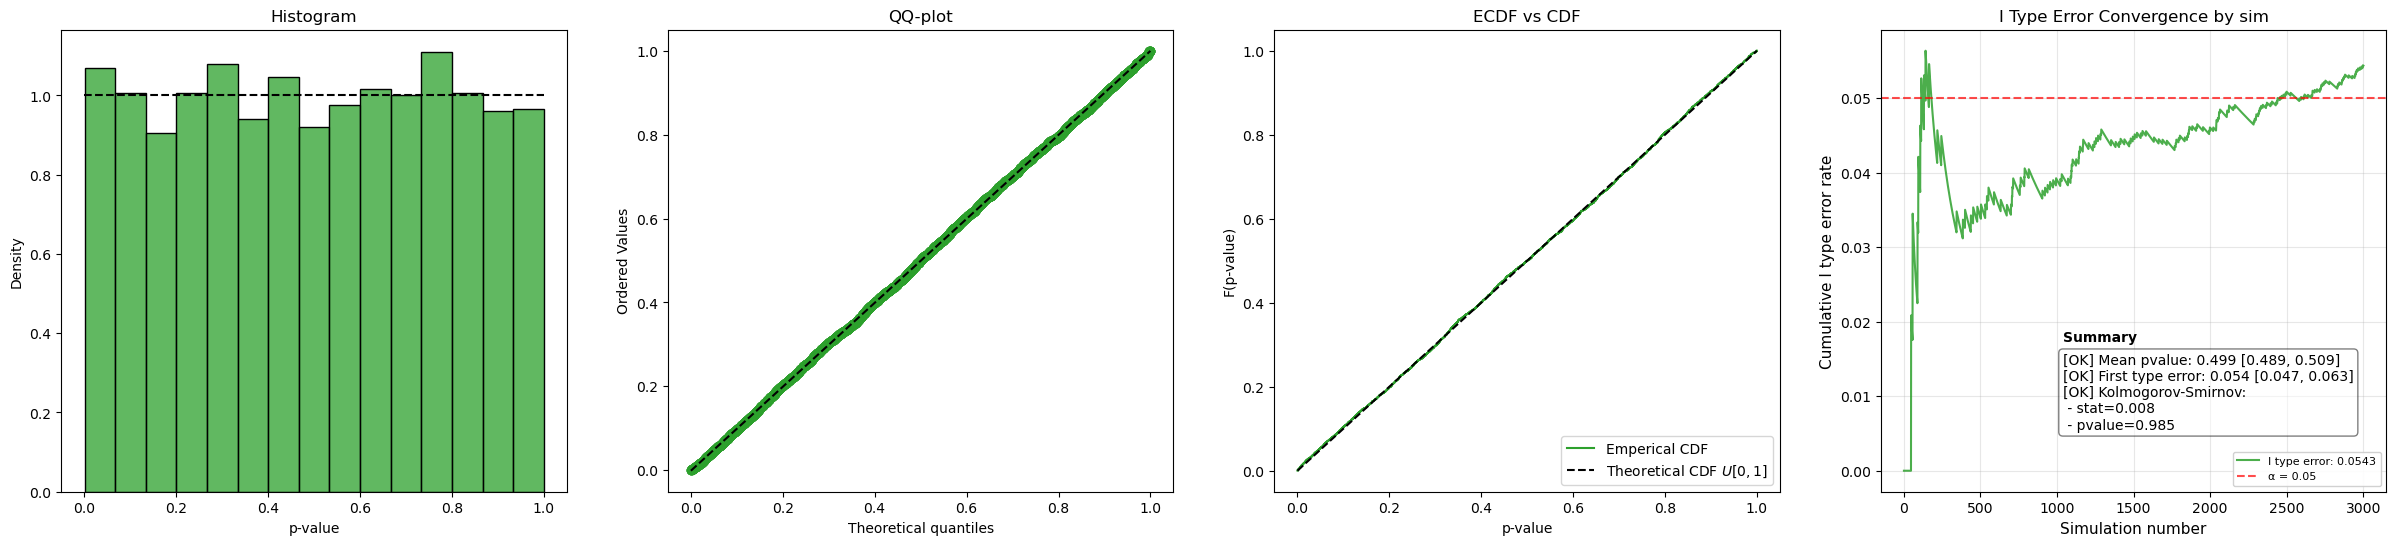

In [10]:
# ── CTR — linearised t-test via DesignerRatioLin ─────────────────────────────
def ttest_lin(test_arr, ctrl_arr):
    """Receives 1-D linearised arrays — plain t-test."""
    return float(scipy_stats.ttest_ind(test_arr, ctrl_arr).pvalue)

print("=== CTR — linearised t-test (DesignerRatioLin) ===")
_ = DesignerRatioLin(
    AaDataRatio(ctr_raw, proportion=True), alpha=0.05, seed=42,
).aa_sims(
    pval_func=ttest_lin,
    n_sims=3_000, control_size=0.5, plot=True, verbose=True, n_jobs=-1,
)


=== Avg Bill — per-user ratio t-test (DesignerRatio) ===


Simulations:   0%|          | 0/3000 [00:00<?, ?sim/s]

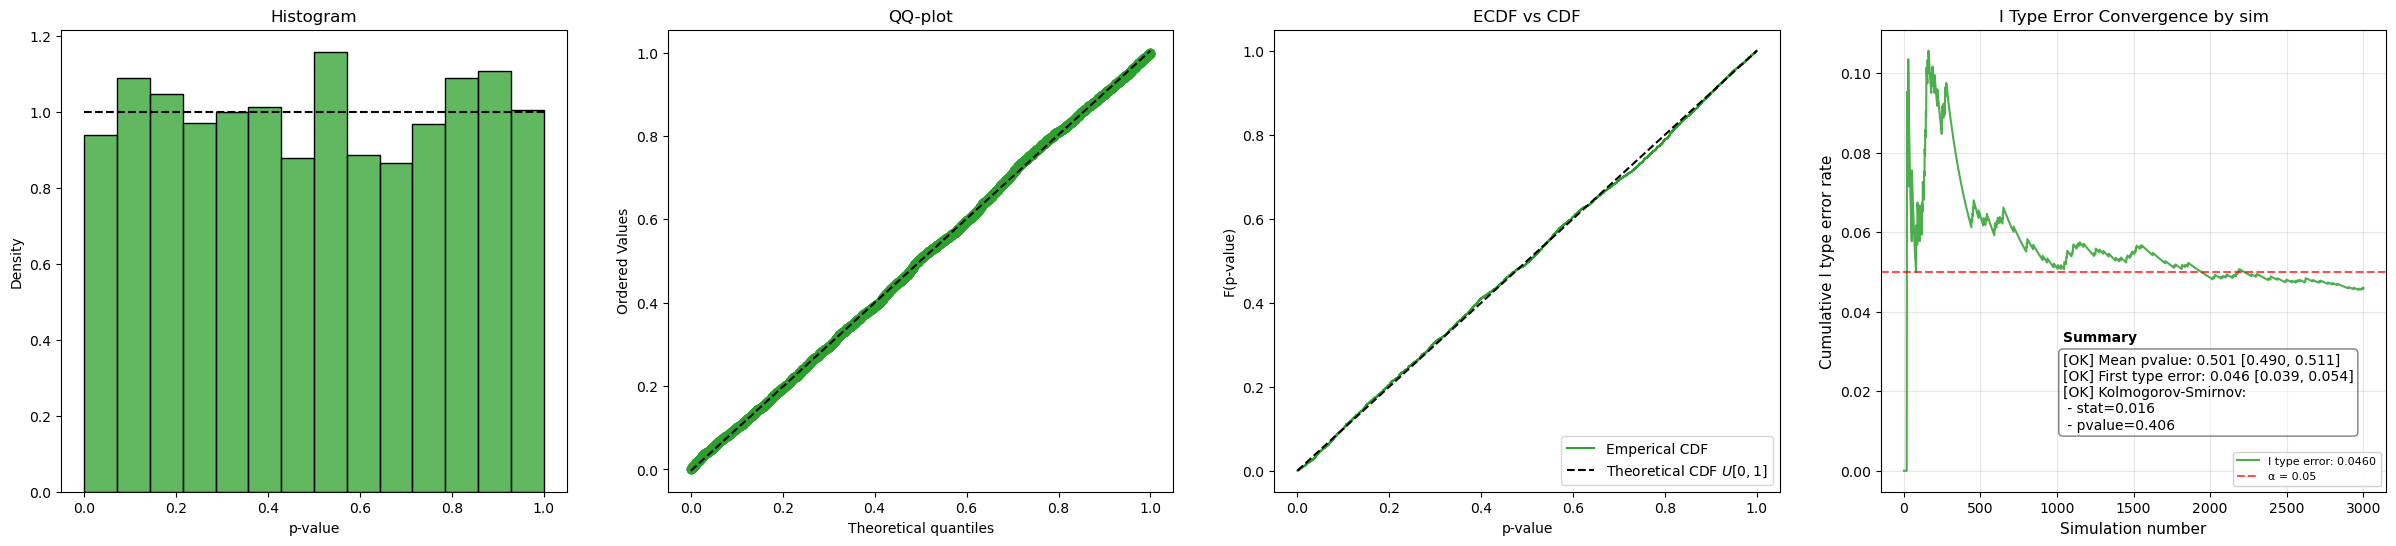

In [11]:
# ── 3.4 Avg Bill — per-user t-test via DesignerRatio ─────────────────────────
def bill_ttest_ratio(test_tuple, ctrl_tuple):
    """Receives (revenue, purchases) tuples."""
    t_rev, t_pur = test_tuple
    c_rev, c_pur = ctrl_tuple
    return float(scipy_stats.ttest_ind(t_rev / t_pur, c_rev / c_pur).pvalue)

print("=== Avg Bill — per-user ratio t-test (DesignerRatio) ===")
_ = DesignerRatio(
    AaDataRatio(avg_bill_raw), alpha=0.05, seed=42,
).aa_sims(
    pval_func=bill_ttest_ratio,
    n_sims=3_000, control_size=0.5, plot=True, verbose=True, n_jobs=-1,
)


Avg bill can be linearized with the same way as CTR - just call `DesignerRatioLin` instead of `DesignerRatio`.

### Test Selection Summary

| Metric type | Data class | Designer | Recommended test | Key risk if wrong |
|---|---|---|---|---|
| ARPU / revenue (heavy tail) | `AaDataIid` | `DesignerIid` | t-test or Mann-Whitney U | Both usually calibrated; MWU more robust to extreme outliers |
| Conversion (0/1) | `AaDataIid(proportion=True)` | `DesignerIid` | t-test | – |
| CTR (clicks / impressions) | `AaDataRatio(proportion=True)` | `DesignerRatio` or `DesignerRatioLin` | Per-user t-test; linearised for better power | **Never** use iid test per impression — actual α explodes to 15–19 % |
| Avg bill (revenue / purchases) | `AaDataRatio` | `DesignerRatio` or `DesignerRatioLin` | Per-user t-test; linearised preferred | High variance without linearization. Linearisation opens way to cuped and poststratification – its option to increse sensitivity |

> **Rule:** always verify your chosen test with `aa_sims(plot=True)` on your real data.
> A green diagnostic is a prerequisite for running the real experiment.


## 4. Reducing α: How Much Data Do You Need?

So far we've used `alpha=0.05`. What if the product requires a stricter threshold — say **α = 0.01**?

> **Important:** setting `alpha=0.01` in the designer constructor only moves the threshold lines
> on the plots. It does **not** automatically make your test properly calibrated at that level.

For skewed metrics (like ARPU with an exponential distribution) the t-test relies on the
Central Limit Theorem. At α = 0.05 the CLT kicks in fast — N ≈ 200–500 is usually enough.
At α = 0.01 we're looking at a **much farther tail**, and the CLT needs more observations to
model it accurately. With too little data, the actual FPR stays above the intended threshold
even though you changed the cutoff.

**How to verify:** run `aa_sims` at the target sample size, call
`first_type_error_ci(pvals, alpha=0.01)`, and check that the observed FPR has reached the
nominal level.

The cell below sweeps across different group sizes and measures the observed FPR at
three significance levels: 0.05, 0.01, and 0.005.


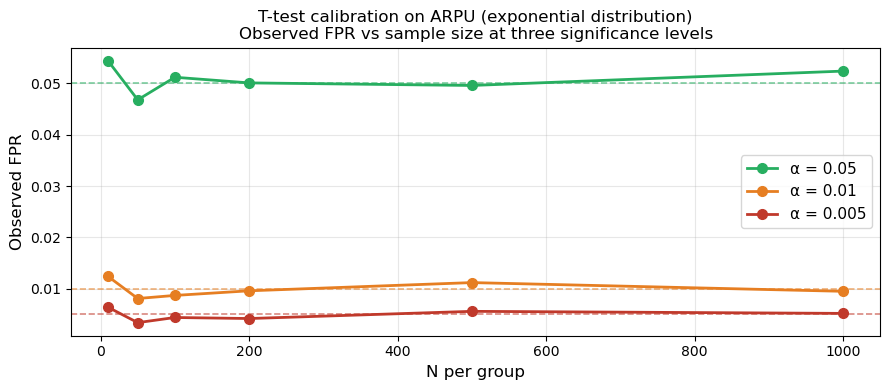

 N per group | α=0.050 | α=0.010 | α=0.005
-------------------------------------------
          10 | 0.0544  | 0.0124  | 0.0064
          50 | 0.0468  | 0.0081  | 0.0034
         100 | 0.0512  | 0.0087  | 0.0044
         200 | 0.0501  | 0.0096  | 0.0042
         500 | 0.0496  | 0.0112  | 0.0056
       1,000 | 0.0524  | 0.0095  | 0.0052


In [27]:
from mcab import RandomData, DesignerIid, AaDataIid
from mcab.core import first_type_error_ci
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt

def ttest(a, b):
    return float(scipy_stats.ttest_ind(a, b).pvalue)

ALPHAS = [0.050, 0.010, 0.005]
SIZES  = [10, 50, 100, 200, 500, 1_000]
N_SIMS = 10_000
COLORS = ['#27ae60', '#e67e22', '#c0392b']

# run aa_sims once per N, measure FPR at three alpha levels from the same p-value vector
fprs = {a: [] for a in ALPHAS}
for n in SIZES:
    pvals = DesignerIid(
        AaDataIid(RandomData(seed=42).exponential_data(size=n * 2)),
        seed=42,
    ).aa_sims(ttest, N_SIMS, control_size=0.5, plot=False, verbose=False, n_jobs=-1)
    for a in ALPHAS:
        fprs[a].append(first_type_error_ci(pvals, alpha=a)[0])

# plot
fig, ax = plt.subplots(figsize=(9, 4))
for a, c in zip(ALPHAS, COLORS):
    ax.plot(SIZES, fprs[a], 'o-', color=c, lw=2, ms=7, label=f'α = {a}')
    ax.axhline(a, color=c, ls='--', lw=1.2, alpha=0.6)
ax.set_xlabel('N per group', fontsize=12)
ax.set_ylabel('Observed FPR', fontsize=12)
ax.set_title(
    'T-test calibration on ARPU (exponential distribution)\n'
    'Observed FPR vs sample size at three significance levels',
    fontsize=12,
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# numeric summary
print(f"{'N per group':>12} | α=0.050 | α=0.010 | α=0.005")
print("-" * 43)
for i, n in enumerate(SIZES):
    print(f"{n:>12,} | {fprs[0.050][i]:.4f}  | {fprs[0.010][i]:.4f}  | {fprs[0.005][i]:.4f}")


### How to read the table

The first row where the observed FPR **drops to (or below) the nominal α** is the
minimum safe group size for that significance level.

In our sandbox case alphas of all levels calibrated well on sample size 200 observations per group.

The stricter the α, the deeper into the tail we test — and the more data the CLT needs
to model that tail accurately. Always verify calibration empirically before going to production
with a tighter significance level.


## 5. What if i want test/control ratio differs from 50/50?  
  
For this purpose you can use `control_size` argument in `aa_sims` method.  
If value in (0, 1) will given - control size is fraction.  
When value is int - control size is number of samples.  

## 📋 Lesson Summary

### Core concepts

| Term | Definition |
|------|-----------|
| **Type I error (α)** | Probability of rejecting H₀ when it is true (false positive) |
| **FPR** | Observed fraction of A/A simulations where p < α |
| **Calibration** | A test is calibrated when observed FPR ≈ nominal α |
| **`first_type_error_ci`** | Returns `(fpr, lower, upper)` — Wilson CI around the observed FPR |

---

### Diagnostic workflow with `aa_sims(plot=True)`

`aa_sims` runs `n_sims` A/A experiments and returns a p-value vector.  
With `plot=True` it renders **4 panels in one row**:

| Panel | What it checks |
|-------|---------------|
| **Histogram** | p-values should be uniform on [0, 1] |
| **QQ-plot** | Empirical quantiles vs Uniform(0, 1) — points on the diagonal ✓ |
| **ECDF** | Empirical CDF vs the ideal diagonal |
| **Convergence + summary box** | Cumulative FPR stabilises as n_sims grows; box shows `mean_p`, `FPR`, `KS p-value` with `[OK]` / `[X]` |

Color coding: 🟢 **green** — all checks pass · 🟠 **orange** — minor issue · 🔴 **red** — serious miscalibration

---

### Test selection by metric type

| Metric | Data container | Designer | p-val function receives |
|--------|---------------|----------|------------------------|
| ARPU, revenue (iid) | `AaDataIid(data)` | `DesignerIid` | two 1-D arrays |
| Conversion rate (0/1) | `AaDataIid(data, proportion=True)` | `DesignerIid` | two 1-D arrays |
| CTR (clicks / impressions) | `AaDataRatio(data, proportion=True)` | `DesignerRatio` | two `(num_arr, denom_arr)` tuples |
| Avg bill (revenue / orders) | `AaDataRatio(data)` | `DesignerRatio` | two `(num_arr, denom_arr)` tuples |
| CTR / avg bill + linearisation | same as above | `DesignerRatioLin` | two 1-D linearised arrays |

---

### Tightening α: what you must do

Setting `alpha=0.01` in the designer only moves threshold lines on the plots.  
To actually achieve FPR = 0.01 you need **both**:

1. Compare p-values against 0.01 (the threshold change)
2. Have enough data so the CLT accurately models the 1 % tail

**Verification recipe:**

```python
pvals = designer.aa_sims(pval_func, n_sims=3_000, control_size=0.5, plot=False, verbose=False)
fpr, lo, hi = first_type_error_ci(pvals, alpha=0.01)
print(f"FPR = {fpr:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
# Goal: hi <= 0.01
